# Day 08. Exercise 04
# Regression

## 0. Imports

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [28]:
data = pd.read_csv('../data/checker_regression.csv')
data.fillna(0, inplace=True)
data

,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,0.00
1,user_1,62,28.0,0.00
2,user_1,62,28.0,0.00
3,user_1,62,28.0,0.00
4,user_1,62,28.0,0.00
...,...,...,...,...
72,user_31,128,0.0,-104.75
73,user_4,40,0.0,-175.60
74,user_6,15,0.0,-62.60
75,user_7,8,0.0,-115.50


In [29]:
data = pd.get_dummies(data, columns=['uid'], drop_first=True)
data

,num_commits,pageviews,AVG(diff),uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,...,uid_user_27,uid_user_28,uid_user_29,uid_user_3,uid_user_30,uid_user_31,uid_user_4,uid_user_6,uid_user_7,uid_user_8
0,62,28.0,0.00,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,62,28.0,0.00,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,62,28.0,0.00,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,62,28.0,0.00,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,62,28.0,0.00,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,128,0.0,-104.75,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
73,40,0.0,-175.60,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
74,15,0.0,-62.60,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
75,8,0.0,-115.50,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [30]:
X = data.drop('AVG(diff)', axis=1)
y = data['AVG(diff)']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [32]:
def crossval(n_splits, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    rmse_results = []
    
    for train_index, test_index in kf.split(X_train):
        X_fold_train, X_fold_test = X_train.iloc[train_index], X_train.iloc[test_index]
        y_fold_train, y_fold_test = y_train.iloc[train_index], y_train.iloc[test_index]
        
        model.fit(X_fold_train, y_fold_train)
        
        y_train_pred = model.predict(X_fold_train)
        y_test_pred = model.predict(X_fold_test)
        
        train_rmse = np.sqrt(mean_squared_error(y_fold_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_fold_test, y_test_pred))
        
        print(f"train - {train_rmse} | test - {test_rmse}")
        rmse_results.append(test_rmse)

    average_rmse = np.mean(rmse_results)
    print(f"Average RMSE on crossval is {average_rmse}")

In [33]:
print("Linear Regression:")
crossval(n_splits=21, model=LinearRegression())

Linear Regression:
train - 4.5473863232196847e-13 | test - 6.884761933401165
train - 1.3825361400909333e-12 | test - 2.0427084153302928e-12
train - 9.46348519038913e-13 | test - 17.27272661265635
train - 7.697938955690738e-13 | test - 6.115072406485188e-13
train - 6.574613461987688e-13 | test - 114.49858490690647
train - 6.70881462904648e-13 | test - 9.254529320040169e-13
train - 1.0065543706811433e-12 | test - 3.61563169562589e-13
train - 9.16805894968204e-13 | test - 8.782798758386492e-13
train - 1.3068098135591374e-12 | test - 2.07079022359449e-12
train - 1.0358630254816002e-12 | test - 1.2529214520866852e-12
train - 7.878424244519166e-13 | test - 4.059432074281432e-13
train - 7.219574853094325e-13 | test - 3.237456027674886e-13
train - 7.556954235464624e-13 | test - 15.504406541819362
train - 1.1197383195342184e-12 | test - 62.15283000362876
train - 6.469552526119148e-13 | test - 23.697268072063082
train - 1.4648061896258862e-12 | test - 124.95988462288297
train - 1.096190561710857

In [34]:
print("\nDecision Tree Regressor:")
crossval(n_splits=21, model=DecisionTreeRegressor(random_state=21))


Decision Tree Regressor:
train - 0.0 | test - 34.98742631289132
train - 0.0 | test - 0.0
train - 0.0 | test - 0.0
train - 0.0 | test - 0.0
train - 0.0 | test - 101.09403213510346
train - 0.0 | test - 0.0
train - 0.0 | test - 0.0
train - 0.0 | test - 0.0
train - 0.0 | test - 0.0
train - 0.0 | test - 0.0
train - 0.0 | test - 0.0
train - 0.0 | test - 0.0
train - 0.0 | test - 33.13990545148452
train - 0.0 | test - 41.22280922013928
train - 0.0 | test - 21.01586702153082
train - 0.0 | test - 99.42295174321337
train - 0.0 | test - 7.120653320005386
train - 0.0 | test - 26.038497140452122
train - 0.0 | test - 86.6875808098638
train - 0.0 | test - 58.706899083497845
train - 0.0 | test - 40.58792924010783
Average RMSE on crossval is 26.191645308489992


In [35]:
print("\nRandom Forest Regressor:")
crossval(n_splits=21, model=RandomForestRegressor(random_state=21))


Random Forest Regressor:
train - 14.054552477503924 | test - 20.0584955022757
train - 14.752485856828958 | test - 0.816373280634131
train - 14.793908176220258 | test - 0.0
train - 13.96452724012631 | test - 0.0
train - 11.57468082353319 | test - 99.11429806205224
train - 15.629012315371138 | test - 0.0
train - 14.960199451617738 | test - 0.0
train - 14.440074702102434 | test - 0.816373280634131
train - 15.474228152193248 | test - 0.0
train - 14.836454343429706 | test - 0.0
train - 14.80085803773742 | test - 0.0
train - 14.469968561555813 | test - 0.0
train - 14.516918088998152 | test - 7.793073933521605
train - 14.715899503246643 | test - 8.219350882273178
train - 13.758630054027961 | test - 35.07292096000367
train - 12.664124209750923 | test - 95.58270920691322
train - 14.48777157630276 | test - 35.918884747183874
train - 14.148637486964875 | test - 24.605513772323473
train - 14.540791852551695 | test - 69.72531894300454
train - 14.356044510280935 | test - 64.05936319886766
train - 1

## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [36]:
lin_reg = LinearRegression()
tree_reg = DecisionTreeRegressor(random_state=21)
forest_reg = RandomForestRegressor(random_state=21)

In [37]:
lin_reg.fit(X_train, y_train)
tree_reg.fit(X_train, y_train)
forest_reg.fit(X_train, y_train)

RandomForestRegressor(random_state=21)

In [38]:
y_pred_lin = lin_reg.predict(X_test)
y_pred_tree = tree_reg.predict(X_test)
y_pred_forest = forest_reg.predict(X_test)

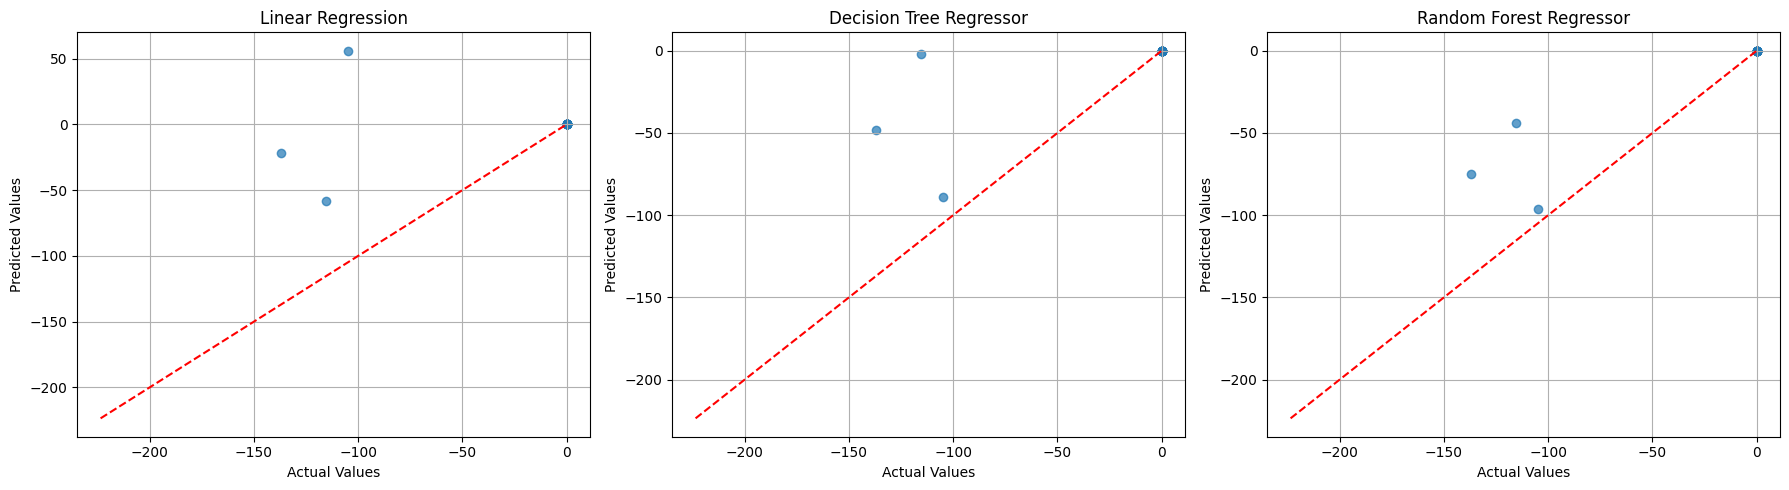

In [39]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_lin, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Ideal line
plt.title('Linear Regression')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid()

plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_tree, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Ideal line
plt.title('Decision Tree Regressor')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid()

plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_forest, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Ideal line
plt.title('Random Forest Regressor')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid()

plt.tight_layout()
plt.show()

## Вот эти вот все черные точки короче должны лежать очень близко к линии пунктирной


